In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv("C:\\Users\\Welcome\\OneDrive\\Desktop\\Advertising.csv")
print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400

In [9]:
# Check missing values
print(df.isnull().sum())

# Drop unnecessary column (if exists)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [11]:
X = df[['TV', 'Radio', 'Newspaper']]   # Advertising factors
y = df['Sales']                       # Target variable

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
#make predictions 
y_pred = model.predict(X_test)

In [19]:
#evaluate model performance
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.4607567168117606
R2 Score: 0.899438024100912


In [21]:
#analyze
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_})
print(coefficients)

     Feature    Impact
0         TV  0.044730
1      Radio  0.189195
2  Newspaper  0.002761


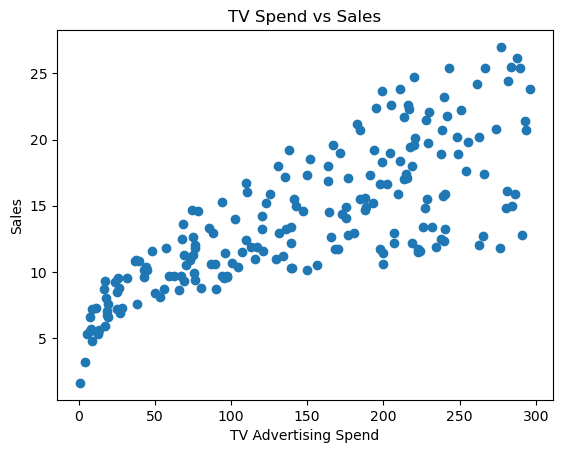

In [23]:
#visualization
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Spend vs Sales")
plt.show()

In [29]:
new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [50]})

prediction = model.predict(new_data)
print("Predicted Sales:", prediction)

Predicted Sales: [19.63082872]
